In [2]:
import pandas as pd

df = pd.read_csv('hotel_bookings.csv')

print(df.shape)

(119390, 32)


In [3]:
# Handle missing values

df['company'] = df['company'].fillna(0)
df['agent'] = df['agent'].fillna(0)
df['country'] = df['country'].fillna(df['country'].mode()[0])
df['children'] = df['children'].fillna(df['children'].median())

In [4]:
# Remove duplicates

df = df.drop_duplicates()

print(df.shape)

(87377, 32)


In [7]:
df.duplicated().sum()

np.int64(0)

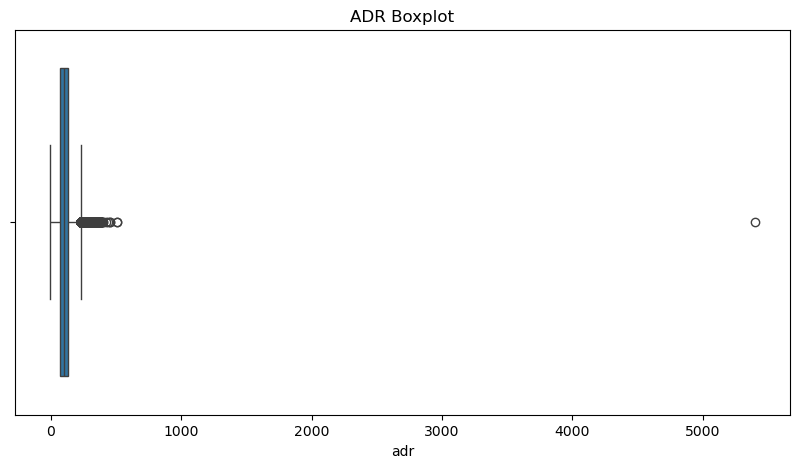

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.boxplot(x=df['adr'])

plt.title('ADR Boxplot')
plt.show()

In [6]:
df['adr'].describe()

count    87377.000000
mean       106.345111
std         55.005117
min         -6.380000
25%         72.000000
50%         98.100000
75%        134.000000
max       5400.000000
Name: adr, dtype: float64

In [8]:
Q1 = df['adr'].quantile(0.25)
Q3 = df['adr'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Q1: 72.0
Q3: 134.0
IQR: 62.0
Lower Bound: -21.0
Upper Bound: 227.0


In [9]:
outliers = df[
    (df['adr'] < lower_bound) |
    (df['adr'] > upper_bound)
]

print(outliers.shape)

(2488, 32)


In [10]:
df = df[
    (df['adr'] >= lower_bound) &
    (df['adr'] <= upper_bound)
]

In [11]:
df.shape

(84889, 32)

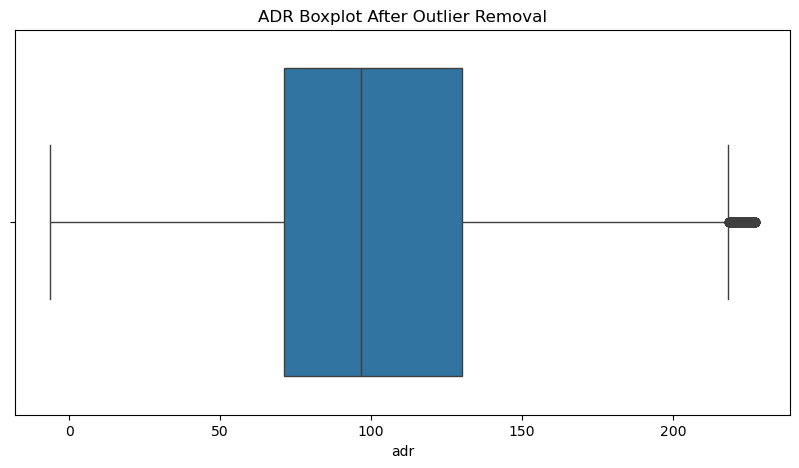

In [12]:
plt.figure(figsize=(10,5))
sns.boxplot(x=df['adr'])

plt.title('ADR Boxplot After Outlier Removal')
plt.show()

In [14]:
#Feature Engineering

df['total_stay_nights'] = (
    df['stays_in_weekend_nights']
    +
    df['stays_in_week_nights']
)

In [15]:
df['total_guests'] = (
    df['adults']
    +
    df['children']
    +
    df['babies']
)

In [16]:
df['total_revenue'] = (
    df['adr']
    *
    df['total_stay_nights']
)

In [17]:
df.shape

(84889, 35)

In [18]:
df[['total_stay_nights',
    'total_guests',
    'total_revenue']].head(10)

,total_stay_nights,total_guests,total_revenue
0,0,2.0,0.0
1,0,2.0,0.0
2,1,1.0,75.0
3,1,1.0,75.0
4,2,2.0,196.0
6,2,2.0,214.0
7,2,2.0,206.0
8,3,2.0,246.0
9,3,2.0,316.5
10,4,2.0,492.0


In [19]:
df[df['total_stay_nights'] == 0][[
    'hotel',
    'stays_in_weekend_nights',
    'stays_in_week_nights',
    'adr'
]].head()

,hotel,stays_in_weekend_nights,stays_in_week_nights,adr
0,Resort Hotel,0,0,0.0
1,Resort Hotel,0,0,0.0
167,Resort Hotel,0,0,0.0
168,Resort Hotel,0,0,0.0
196,Resort Hotel,0,0,0.0


In [20]:
print("Shape:", df.shape)

print("Missing Values:",
      df.isnull().sum().sum())

print("Duplicates:",
      df.duplicated().sum())

Shape: (84889, 35)
Missing Values: 0
Duplicates: 0


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 84889 entries, 0 to 119389
Data columns (total 35 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel                           84889 non-null  object 
 1   is_canceled                     84889 non-null  int64  
 2   lead_time                       84889 non-null  int64  
 3   arrival_date_year               84889 non-null  int64  
 4   arrival_date_month              84889 non-null  object 
 5   arrival_date_week_number        84889 non-null  int64  
 6   arrival_date_day_of_month       84889 non-null  int64  
 7   stays_in_weekend_nights         84889 non-null  int64  
 8   stays_in_week_nights            84889 non-null  int64  
 9   adults                          84889 non-null  int64  
 10  children                        84889 non-null  float64
 11  babies                          84889 non-null  int64  
 12  meal                            8488

In [22]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,...,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests,total_stay_nights,total_guests,total_revenue
count,84889.000000,84889.000000,84889.000000,84889.000000,84889.000000,84889.000000,84889.00000,84889.000000,84889.000000,84889.000000,...,84889.000000,84889.000000,84889.000000,84889.000000,84889.000000,84889.000000,84889.000000,84889.000000,84889.000000,84889.000000
mean,0.271637,80.150444,2016.199637,26.721907,15.798337,1.001319,2.61313,1.866755,0.117683,0.010472,...,0.268822,78.846258,11.307001,0.768250,101.788429,0.082013,0.693541,3.614449,1.994911,373.848770
std,0.444806,86.460475,0.685912,13.812371,8.842121,1.032651,2.05764,0.627788,0.416169,0.112255,...,0.724677,109.037505,54.687341,10.145598,45.205950,0.278223,0.827720,2.767990,0.768068,334.516873
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.00000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,-6.380000,0.000000,0.000000,0.000000,0.000000,-63.800000
25%,0.000000,11.000000,2016.000000,15.000000,8.000000,0.000000,1.00000,2.000000,0.000000,0.000000,...,0.000000,9.000000,0.000000,0.000000,71.100000,0.000000,0.000000,2.000000,2.000000,150.000000
50%,0.000000,49.000000,2016.000000,27.000000,16.000000,1.000000,2.00000,2.000000,0.000000,0.000000,...,0.000000,9.000000,0.000000,0.000000,96.530000,0.000000,0.000000,3.000000,2.000000,291.600000
75%,1.000000,125.000000,2017.000000,37.000000,23.000000,2.000000,3.00000,2.000000,0.000000,0.000000,...,0.000000,195.000000,0.000000,0.000000,130.000000,0.000000,1.000000,5.000000,2.000000,484.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.00000,55.000000,10.000000,10.000000,...,21.000000,535.000000,543.000000,391.000000,227.000000,8.000000,5.000000,69.000000,55.000000,7590.000000


In [23]:
df['children'] = df['children'].astype(int)
df['agent'] = df['agent'].astype(int)
df['company'] = df['company'].astype(int)
df['total_guests'] = df['total_guests'].astype(int)

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 84889 entries, 0 to 119389
Data columns (total 35 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel                           84889 non-null  object 
 1   is_canceled                     84889 non-null  int64  
 2   lead_time                       84889 non-null  int64  
 3   arrival_date_year               84889 non-null  int64  
 4   arrival_date_month              84889 non-null  object 
 5   arrival_date_week_number        84889 non-null  int64  
 6   arrival_date_day_of_month       84889 non-null  int64  
 7   stays_in_weekend_nights         84889 non-null  int64  
 8   stays_in_week_nights            84889 non-null  int64  
 9   adults                          84889 non-null  int64  
 10  children                        84889 non-null  int64  
 11  babies                          84889 non-null  int64  
 12  meal                            8488

In [25]:
df.to_csv(
    'hotel_bookings_cleaned.csv',
    index=False
)

In [26]:
pd.read_csv('hotel_bookings_cleaned.csv').shape

(84889, 35)

In [27]:
import os
os.listdir()

['.anaconda',
 '.android',
 '.conda',
 '.continuum',
 '.copilot',
 '.git',
 '.gitconfig',
 '.insomniac',
 '.ipynb_checkpoints',
 '.ipython',
 '.jupyter',
 '.matplotlib',
 '.ms-ad',
 '.spss',
 '.vscode',
 '.vscode-shared',
 'Amazon Sales Project.csv',
 'anaconda3',
 'AppData',
 'Application Data',
 'Boolean.ipynb',
 'Class&Object.ipynb',
 'cleaned_superstore.csv',
 'Coffe_sales[1].csv',
 'Comparison.ipynb',
 'Constructor.ipynb',
 'Contacts',
 'Cookies',
 'Customer Shopping Dataset - Retail Sales Data(Project1).csv',
 'Documents',
 'Downloads',
 'Favorites',
 'For loop task.ipynb',
 'Functions.ipynb',
 'hotel_bookings.csv',
 'hotel_bookings_cleaned.csv',
 'Hotel_Bookings_Project.ipynb',
 'ifelse.ipynb',
 'Links',
 'list.ipynb',
 'Local Settings',
 'LTSD Task.ipynb',
 'Matplotlib.ipynb',
 'Mixed ques.ipynb',
 'Multiple Inheritance.ipynb',
 'Music',
 'My Documents',
 'NetHood',
 'NTUSER.DAT',
 'ntuser.dat.LOG1',
 'ntuser.dat.LOG2',
 'NTUSER.DAT{ffc53c6e-4362-11f0-96d8-a5fe50fd5094}.TM.blf'

In [5]:
import pandas as pd
df = pd.read_csv("hotel_bookings_cleaned.csv")

print(df.shape)
df.head()

(84889, 35)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,total_stay_nights,total_guests,total_revenue
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,0,Transient,0.0,0,0,Check-Out,7/1/2015,0,2,0.0
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,0,Transient,0.0,0,0,Check-Out,7/1/2015,0,2,0.0
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,0,Transient,75.0,0,0,Check-Out,7/2/2015,1,1,75.0
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,0,Transient,75.0,0,0,Check-Out,7/2/2015,1,1,75.0
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,0,Transient,98.0,0,1,Check-Out,7/3/2015,2,2,196.0
